In [1]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#create a dataset
data = {
    "Size_m2": [50, 60, 70, 80, 90, 100, 110, 120, 130, 140,
                150, 160, 170, 180, 190, 200, 220, 240, 260, 280],

    "Bedrooms": [1, 1, 2, 2, 2, 3, 3, 3, 3, 4,
                  4, 4, 4, 5, 5, 5, 5, 5, 6, 6],

    "Bathrooms": [1, 1, 1, 2, 2, 2, 2, 2, 2, 3,
                   3, 3, 3, 3, 4, 4, 4, 4, 5, 5],

    "Age": [20, 18, 15, 12, 10, 9, 8, 7, 6, 6,
            5, 5, 4, 4, 3, 3, 2, 2, 1, 1],

    "Distance_km": [15, 14, 13, 12, 11, 10, 10, 9, 9, 8,
                    8, 7, 7, 6, 6, 5, 5, 4, 3, 2],

    "Price_million": [12, 14, 17, 20, 23, 27, 30, 33, 36, 40,
                      43, 46, 50, 55, 59, 63, 70, 78, 87, 95]
}

df = pd.DataFrame(data)

df.head()

,Size_m2,Bedrooms,Bathrooms,Age,Distance_km,Price_million
0,50,1,1,20,15,12
1,60,1,1,18,14,14
2,70,2,1,15,13,17
3,80,2,2,12,12,20
4,90,2,2,10,11,23


In [4]:
#explore the data as follows 
df.shape #this shows the rows and columns 

(20, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Size_m2        20 non-null     int64
 1   Bedrooms       20 non-null     int64
 2   Bathrooms      20 non-null     int64
 3   Age            20 non-null     int64
 4   Distance_km    20 non-null     int64
 5   Price_million  20 non-null     int64
dtypes: int64(6)
memory usage: 1.1 KB


In [6]:
df.describe()

,Size_m2,Bedrooms,Bathrooms,Age,Distance_km,Price_million
count,20.0000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,150.0000,3.650000,2.800000,7.050000,8.200000,44.900000
std,67.2779,1.531253,1.239694,5.500957,3.621573,24.462431
min,50.0000,1.000000,1.000000,1.000000,2.000000,12.000000
25%,97.5000,2.750000,2.000000,3.000000,5.750000,26.000000
50%,145.0000,4.000000,3.000000,5.500000,8.000000,41.500000
75%,192.5000,5.000000,4.000000,9.250000,10.250000,60.000000
max,280.0000,6.000000,5.000000,20.000000,15.000000,95.000000


In [7]:
df.isnull().sum()

Size_m2          0
Bedrooms         0
Bathrooms        0
Age              0
Distance_km      0
Price_million    0
dtype: int64

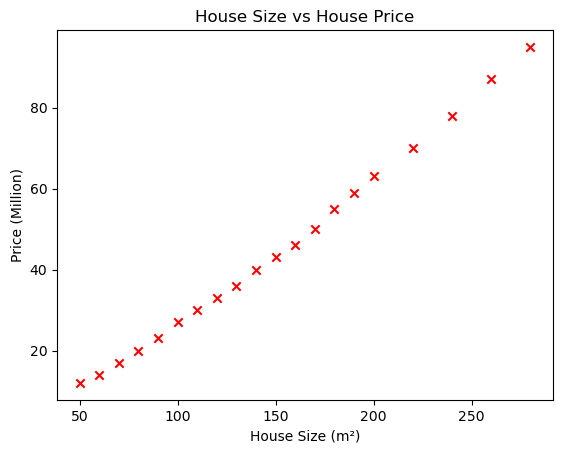

In [10]:
#Before training a model, it is important to inspect your data
# This explains how house prices increase with respect to the house sizes
#Visualize the data
plt.scatter(df["Size_m2"], df["Price_million"], marker='x',c='r')

plt.xlabel("House Size (m²)")
plt.ylabel("Price (Million)")
plt.title("House Size vs House Price")

plt.show()

In [14]:
#Define X and y
# hence, the features are;
X = df[["Size_m2", "Bedrooms", "Bathrooms", "Age", "Distance_km"]]
X

,Size_m2,Bedrooms,Bathrooms,Age,Distance_km
0,50,1,1,20,15
1,60,1,1,18,14
2,70,2,1,15,13
3,80,2,2,12,12
4,90,2,2,10,11
5,100,3,2,9,10
6,110,3,2,8,10
7,120,3,2,7,9
8,130,3,2,6,9
9,140,4,3,6,8


In [15]:
#The target y
y = df["Price_million"]
y

0     12
1     14
2     17
3     20
4     23
5     27
6     30
7     33
8     36
9     40
10    43
11    46
12    50
13    55
14    59
15    63
16    70
17    78
18    87
19    95
Name: Price_million, dtype: int64

In [17]:
#Split the data set
# Data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16, 5)
Testing data: (4, 5)


In [20]:
#Train the ML model
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
#Make prediction 
y_pred = model.predict(X_test)

print(y_pred) 

[13.51832475 78.51203039 63.1449222  16.16639497]


In [23]:
#Evaluate the model
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae) # mae tells us how far the predictions are from the actual values

MAE: 1.0854180779413465


In [24]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 1.349236337414253


In [27]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

# R^2 ~ 1 (Execellent fit), R^2 ~ 0.8 (Good), R^2 ~ 0.6 (Moderate), R^2 ~ Poor
# The exact interpretation depends on the problem and the dataset

R² Score: 0.9978712987570574


In [28]:
#Compare Actual vs Predicted
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results

,Actual,Predicted
0,12,13.518325
1,78,78.512030
2,63,63.144922
3,14,16.166395


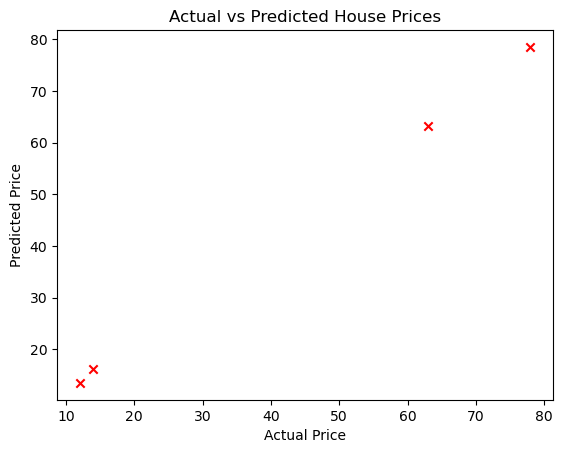

In [31]:
# Visualize the prediction

plt.scatter(y_test, y_pred, marker='x', c='r')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

#Predict the new house 
Size = 180 m²
Bedrooms = 4
Bathrooms = 3
Age = 5 years
Distance = 6 km

In [33]:
#Predict the new house
new_house = np.array([[180, 4, 3, 5, 6]])

predicted_price = model.predict(new_house)

print("Predicted house price:", predicted_price[0], "million")

Predicted house price: 56.15191761591576 million


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# MACHINE LEARNING REGRESSION 